1. Tải bộ dữ liệu

In [46]:
!gdown 1SFWQ7Zi83Gff-RVrlHj0z4Llm1Nq4BBA

Downloading...
From: https://drive.google.com/uc?id=1SFWQ7Zi83Gff-RVrlHj0z4Llm1Nq4BBA
To: /content/titanic_modified_dataset.csv
100% 25.9k/25.9k [00:00<00:00, 47.0MB/s]


2. Import libraries

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

3. Đọc dữ liệu

In [48]:
dataset_path = 'titanic_modified_dataset.csv'
df = pd.read_csv(
    dataset_path,
    index_col ='PassengerId'
)
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Survived
PassengerId,,,,,,,,,
1,3,0,22.0,1,0,7.2500,0,0,0
2,1,1,38.0,1,0,71.2833,1,1,1
3,3,1,26.0,0,0,7.9250,0,2,1
4,1,1,35.0,1,0,53.1000,0,1,1
5,3,0,35.0,0,0,8.0500,0,0,0
...,...,...,...,...,...,...,...,...,...
887,2,0,27.0,0,0,13.0000,0,5,0
888,1,1,19.0,0,0,30.0000,0,2,1
889,3,1,28.0,1,2,23.4500,0,2,0


4. Chia biến X, y

In [49]:
dataset_arr = df.to_numpy().astype(np.float64)
X, y = dataset_arr[:, :-1], dataset_arr[:, -1]

In [50]:
print('X shape:', X.shape)

X shape: (891, 8)


5. Thêm bias vào X

In [51]:
intercept = np.ones((
    X.shape[0], 1)
)
X_b = np.concatenate(
    (intercept, X),
    axis=1
)

In [52]:
print(X_b.shape)

(891, 9)


6. Chia tập train, val, test

In [53]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_b, y,
    test_size = val_size,
    random_state = random_state,
    shuffle = is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size = test_size,
    random_state = random_state,
    shuffle = is_shuffle
)

In [54]:
print(f'Number of training samples: {X_train.shape[0]}')
print(f'Number of validation samples: {X_val.shape[0]}')
print(f'Number of testing samples: {X_test.shape[0]}')

Number of training samples: 623
Number of validation samples: 179
Number of testing samples: 89


7. Chuẩn hóa dữ liệu

In [55]:
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val [:, 1:] = normalizer.transform(X_val[:, 1:])
X_test [:, 1:] = normalizer.transform(X_test[:, 1:])

In [56]:
X_train

array([[ 1.        ,  0.8380325 , -0.73366996, ..., -0.34812766,
         0.89679528, -0.55130115],
       [ 1.        , -1.55141486, -0.73366996, ...,  1.76556546,
        -0.60106922, -0.55130115],
       [ 1.        ,  0.8380325 , -0.73366996, ..., -0.47988477,
        -0.60106922, -0.55130115],
       ...,
       [ 1.        ,  0.8380325 , -0.73366996, ..., -0.48238806,
         2.39465977, -0.55130115],
       [ 1.        ,  0.8380325 , -0.73366996, ..., -0.22655193,
        -0.60106922, -0.55130115],
       [ 1.        ,  0.8380325 , -0.73366996, ..., -0.05432564,
         2.39465977,  1.3289577 ]])

8. Cài đặt các hàm quan trọng

In [57]:
#Hàm sigmoid
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

In [58]:
#Hàm dự đoán
def predict(X, theta):
  dot_product = np.dot(X, theta)
  y_hat = sigmoid(dot_product)

  return y_hat

In [59]:
# Hàm tính loss
def compute_loss(y_hat, y):
    y_hat = np.clip(y_hat, 1e-7, 1 - 1e-7)

    return (-y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)).mean()


In [60]:
#Hàm tính gradient
def compute_gradient(X, y, y_hat):
  return np.dot(
      X.T,(y_hat - y)
      ) / y.size

In [61]:
#Hàm cập nhật trọng số
def update_theta(theta, gradient, lr):
  return theta - lr * gradient

In [62]:
#Hàm tính độ chính xác
def compute_accuracy(X, y, theta):
  y_hat = predict(X, theta).round()
  acc = (y_hat == y).mean()

  return acc

9. Khai báo các siêu tham số và khởi tạo weights

In [63]:
lr = 0.01
epochs = 100
batch_size = 16

np.random.seed(random_state)
theta = np.random.uniform(
    size = X_train.shape[1]
)

10. Huấn luyện mô hình

In [64]:
train_accs = []
train_losses = []
val_accs = []
val_losses = []

for epoch in range(epochs):
    train_batch_losses = []
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        X_i = X_train[i:i + batch_size]
        y_i = y_train[i:i + batch_size]

        # Prediction
        y_hat = predict(X_i, theta)

        # Compute loss
        train_loss = compute_loss(y_hat, y_i)

        # Compute gradient and update theta
        gradient = compute_gradient(X_i, y_i, y_hat)
        theta = update_theta(theta, gradient, lr)

        # Append training loss and accuracy for this batch
        train_batch_losses.append(train_loss)
        train_acc = compute_accuracy(X_i, y_i, theta)
        train_batch_accs.append(train_acc)

    # Validation after each epoch
    y_val_hat = predict(X_val, theta)
    val_loss = compute_loss(y_val_hat, y_val)
    val_batch_losses.append(val_loss)
    val_acc = compute_accuracy(X_val, y_val, theta)
    val_batch_accs.append(val_acc)

    # Calculate average losses and accuracies
    train_batch_loss = sum(train_batch_losses) / len(train_batch_losses)
    val_batch_loss = sum(val_batch_losses) / len(val_batch_losses)
    train_batch_acc = sum(train_batch_accs) / len(train_batch_accs)
    val_batch_acc = sum(val_batch_accs) / len(val_batch_accs)

    # Append epoch-level losses and accuracies
    train_losses.append(train_batch_loss)
    val_losses.append(val_batch_loss)
    train_accs.append(train_batch_acc)
    val_accs.append(val_batch_acc)

    # Print progress
    print(f'\nEPOCH {epoch + 1}: Training loss: {train_batch_loss:.3f}, Validation loss: {val_batch_loss:.3f}')


EPOCH 1: Training loss: 0.703, Validation loss: 0.590

EPOCH 2: Training loss: 0.670, Validation loss: 0.574

EPOCH 3: Training loss: 0.640, Validation loss: 0.560

EPOCH 4: Training loss: 0.614, Validation loss: 0.549

EPOCH 5: Training loss: 0.592, Validation loss: 0.539

EPOCH 6: Training loss: 0.572, Validation loss: 0.531

EPOCH 7: Training loss: 0.554, Validation loss: 0.524

EPOCH 8: Training loss: 0.539, Validation loss: 0.519

EPOCH 9: Training loss: 0.526, Validation loss: 0.514

EPOCH 10: Training loss: 0.514, Validation loss: 0.511

EPOCH 11: Training loss: 0.504, Validation loss: 0.508

EPOCH 12: Training loss: 0.495, Validation loss: 0.506

EPOCH 13: Training loss: 0.487, Validation loss: 0.504

EPOCH 14: Training loss: 0.480, Validation loss: 0.503

EPOCH 15: Training loss: 0.474, Validation loss: 0.502

EPOCH 16: Training loss: 0.468, Validation loss: 0.501

EPOCH 17: Training loss: 0.463, Validation loss: 0.500

EPOCH 18: Training loss: 0.459, Validation loss: 0.500



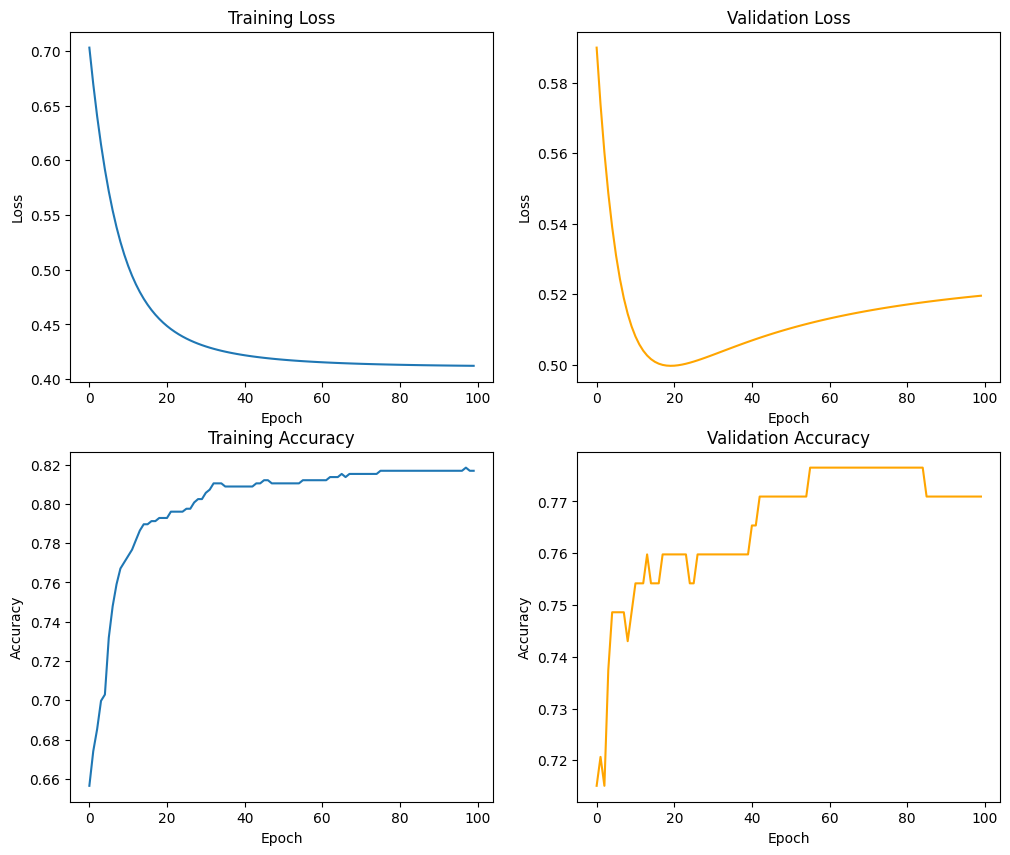

In [65]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Training Loss
ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

# Validation Loss
ax[0, 1].plot(val_losses, color='orange')  # Fixed color specification
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

# Training Accuracy
ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

# Validation Accuracy
ax[1, 1].plot(val_accs, color='orange')  # Fixed color specification
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()


11. Đánh giá mô hình

In [67]:
val_set_acc = compute_accuracy(X_val, y_val, theta)
test_set_acc = compute_accuracy(X_test, y_test, theta)

print('Evaluation on validation and test set:')
print(f'Validation Set Accuracy: {val_set_acc:.3f}')
print(f'Test Set Accuracy: {test_set_acc:.3f}')


Evaluation on validation and test set:
Validation Set Accuracy: 0.771
Test Set Accuracy: 0.775
